# Notebook 20 — DINOv2 Efficiency Frontier

## Research Question

How does cross-script writer-verification performance scale across compact-to-giant DINOv2 representations under the same writer-disjoint QUWI protocol, and where does the current compact task-specific verifier lie on the accuracy–parameter frontier?

## Goals

- Benchmark DINOv2 ViT-S/14-Reg and ViT-B/14-Reg.
- Evaluate both frozen cosine verification and development-only writer-LDA adaptation.
- Reuse the existing DINOv2-L and DINOv2-G results from Notebook 19.
- Compare against the current compact batch-alternating script-adversarial verifier.
- Build an accuracy–parameter efficiency frontier.
- Keep the official test split untouched.

## Experimental Principle

All comparisons use the same development/validation split, fixed validation verification pairs, cosine scoring, AUC/EER metrics, and six page-pair conditions used in the previous verification experiments.

In [22]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score, roc_curve

from torch.utils.data import DataLoader

from sklearn.decomposition import PCA

from handwriting_cross_script_research.dataset import QUWIDataset

In [2]:
current_path = Path.cwd().resolve()

PROJECT_ROOT = next(
    path
    for path in [
        current_path,
        *current_path.parents,
    ]
    if (
        path
        / "pyproject.toml"
    ).exists()
)

IMAGE_DIR = (
    Path.home()
    / "Documents"
    / "Handwriting"
    / "QUWI"
    / "extracted"
    / "images"
)

NOTEBOOK19_REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "modern_baseline_benchmarking"
)

NOTEBOOK19_SUMMARY_PATH = (
    NOTEBOOK19_REPORT_DIR
    / "modern_baseline_summary.csv"
)

TRAIN_DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

split_candidates = sorted(
    path
    for path in PROJECT_ROOT.rglob(
        "*.csv"
    )
    if "split" in path.name.lower()
)

pair_candidates = sorted(
    path
    for path in PROJECT_ROOT.rglob(
        "*.csv"
    )
    if "pair" in path.name.lower()
)

notebook19_summary_df = pd.read_csv(
    NOTEBOOK19_SUMMARY_PATH
)

print(
    "Project root:",
    PROJECT_ROOT,
)

print(
    "Image directory:",
    IMAGE_DIR,
)

print(
    "Images:",
    len(
        list(
            IMAGE_DIR.glob(
                "*.jpg"
            )
        )
    ),
)

print(
    "Device:",
    TRAIN_DEVICE,
)

print(
    "PyTorch:",
    torch.__version__,
)

print()

print(
    "Split candidates:"
)

for path in split_candidates:
    print(
        path.relative_to(
            PROJECT_ROOT
        )
    )

print()

print(
    "Pair candidates:"
)

for path in pair_candidates:
    print(
        path.relative_to(
            PROJECT_ROOT
        )
    )

print()

print(
    "Notebook 19 benchmark:"
)

print(
    notebook19_summary_df
    .head(5)
    .round(6)
    .to_string(
        index=False
    )
)

Project root: C:\Users\com\Documents\handwriting-cross-script-research
Image directory: C:\Users\com\Documents\Handwriting\QUWI\extracted\images
Images: 1900
Device: cuda
PyTorch: 2.11.0+cu130

Split candidates:
reports\eda\split_condition_summary.csv
splits\quwi_writer_disjoint_split_seed42.csv

Pair candidates:
reports\script_reliance_intervention\paired_cross_script_reliance.csv
reports\ssl_initialized_metric_learning\dynamic_training_pair_schedule.csv
reports\supervised_metric_learning\training_pair_manifest.csv
reports\verification_protocol\pair_balance_audit.csv
reports\verification_protocol\pair_condition_summary.csv
reports\writer_aware_dynamic_sampling\dynamic_training_pair_schedule.csv
reports\writer_aware_dynamic_sampling\epoch_pair_summary.csv
splits\verification\quwi_official_test_verification_pairs.csv
splits\verification\quwi_validation_verification_pairs.csv

Notebook 19 benchmark:
                     model             adaptation  overall_auc      eer  cross_script_mac

In [7]:
SPLIT_PATH = (
    PROJECT_ROOT
    / "splits"
    / "quwi_writer_disjoint_split_seed42.csv"
)

VALIDATION_PAIR_PATH = (
    PROJECT_ROOT
    / "splits"
    / "verification"
    / "quwi_validation_verification_pairs.csv"
)

split_df = pd.read_csv(
    SPLIT_PATH
)

validation_pairs_df = pd.read_csv(
    VALIDATION_PAIR_PATH
)

development_df = (
    split_df[
        split_df[
            "experiment_split"
        ] == "development_train"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_df = (
    split_df[
        split_df[
            "experiment_split"
        ] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

development_dataset = QUWIDataset(
    metadata=development_df,
    image_dir=IMAGE_DIR,
    target_size=(384,384),
)

validation_dataset = QUWIDataset(
    metadata=validation_df,
    image_dir=IMAGE_DIR,
    target_size=(384,384),
)

CONDITION_BY_PAGE_PAIR = {
    (1, 2): "arabic_variable_same",
    (3, 4): "english_variable_same",
    (1, 3): "cross_variable_variable",
    (1, 4): "cross_variable_same",
    (2, 3): "cross_same_variable",
    (2, 4): "cross_same_same",
}

WITHIN_SCRIPT_CONDITIONS = [
    "arabic_variable_same",
    "english_variable_same",
]

CROSS_SCRIPT_CONDITIONS = [
    "cross_variable_variable",
    "cross_variable_same",
    "cross_same_variable",
    "cross_same_same",
]


def calculate_interpolated_eer(
    labels,
    scores,
):
    fpr, tpr, thresholds = roc_curve(
        labels,
        scores,
    )

    fnr = 1.0 - tpr
    difference = fpr - fnr

    crossing_indices = np.where(
        np.diff(
            np.sign(
                difference
            )
        ) != 0
    )[0]

    if len(
        crossing_indices
    ) == 0:
        nearest_index = np.argmin(
            np.abs(
                difference
            )
        )

        eer = (
            fpr[
                nearest_index
            ]
            + fnr[
                nearest_index
            ]
        ) / 2.0

        threshold = thresholds[
            nearest_index
        ]

        return float(
            eer
        ), float(
            threshold
        )

    index = crossing_indices[
        0
    ]

    x0 = difference[
        index
    ]

    x1 = difference[
        index
        + 1
    ]

    weight = (
        -x0
        / (
            x1
            - x0
        )
    )

    eer = (
        fpr[
            index
        ]
        + weight
        * (
            fpr[
                index
                + 1
            ]
            - fpr[
                index
            ]
        )
    )

    threshold = (
        thresholds[
            index
        ]
        + weight
        * (
            thresholds[
                index
                + 1
            ]
            - thresholds[
                index
            ]
        )
    )

    return float(
        eer
    ), float(
        threshold
    )


def filename_page_id(
    filename,
):
    return int(
        Path(
            filename
        ).stem.split(
            "_"
        )[-1]
    )


batch_alt_row = notebook19_summary_df[
    notebook19_summary_df[
        "model"
    ] == "batch_alt_adversarial_mean"
].iloc[0]

dinov2_l_row = notebook19_summary_df[
    (
        notebook19_summary_df[
            "model"
        ] == "dinov2_vitl14_reg"
    )
    & (
        notebook19_summary_df[
            "adaptation"
        ] == "writer_lda"
    )
].iloc[0]

dinov2_g_row = notebook19_summary_df[
    (
        notebook19_summary_df[
            "model"
        ] == "dinov2_vitg14_reg"
    )
    & (
        notebook19_summary_df[
            "adaptation"
        ] == "writer_lda"
    )
].iloc[0]

print(
    "Development:",
    development_df[
        "writer"
    ].nunique(),
    "writers /",
    len(
        development_df
    ),
    "images",
)

print(
    "Validation:",
    validation_df[
        "writer"
    ].nunique(),
    "writers /",
    len(
        validation_df
    ),
    "images",
)

print(
    "Validation pairs:",
    len(
        validation_pairs_df
    ),
)

print()

print(
    "Batch-alt overall AUC:",
    batch_alt_row[
        "overall_auc"
    ],
)

print(
    "DINOv2-L + LDA AUC:",
    dinov2_l_row[
        "overall_auc"
    ],
)

print(
    "DINOv2-G + LDA AUC:",
    dinov2_g_row[
        "overall_auc"
    ],
)

Development: 226 writers / 904 images
Validation: 56 writers / 224 images
Validation pairs: 18816

Batch-alt overall AUC: 0.7773429715952037
DINOv2-L + LDA AUC: 0.8274522972067615
DINOv2-G + LDA AUC: 0.8656665507111936


In [5]:
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

DINOV2_INPUT_SIZE = 518
DINOV2_S_MODEL_NAME = "dinov2_vits14_reg"

dinov2_mean = torch.tensor(
    [0.485, 0.456, 0.406],
    device=TRAIN_DEVICE,
).view(
    1,
    3,
    1,
    1,
)

dinov2_std = torch.tensor(
    [0.229, 0.224, 0.225],
    device=TRAIN_DEVICE,
).view(
    1,
    3,
    1,
    1,
)

dinov2_s_model = torch.hub.load(
    "facebookresearch/dinov2:main",
    DINOV2_S_MODEL_NAME,
    trust_repo=True,
    skip_validation=True,
)

dinov2_s_model = dinov2_s_model.to(
    TRAIN_DEVICE
)

dinov2_s_model.eval()

for parameter in dinov2_s_model.parameters():
    parameter.requires_grad = False

dummy_image = torch.zeros(
    1,
    3,
    384,
    384,
    device=TRAIN_DEVICE,
)

with torch.inference_mode():
    dummy_processed = torch.nn.functional.interpolate(
        dummy_image,
        size=(
            DINOV2_INPUT_SIZE,
            DINOV2_INPUT_SIZE,
        ),
        mode="bicubic",
        align_corners=False,
    )

    dummy_processed = (
        dummy_processed
        - dinov2_mean
    ) / dinov2_std

    dummy_embedding = dinov2_s_model(
        dummy_processed
    )

DINOV2_S_PARAMETERS = sum(
    parameter.numel()
    for parameter in dinov2_s_model.parameters()
)

print(
    "Model:",
    DINOV2_S_MODEL_NAME,
)

print(
    "Parameters:",
    DINOV2_S_PARAMETERS,
)

print(
    "Embedding shape:",
    dummy_embedding.shape,
)

print()

del dummy_image
del dummy_processed
del dummy_embedding

dinov2_s_batch_results = []

for batch_size in [
    32,
    64,
    96,
    128,
]:
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    try:
        probe_images = torch.zeros(
            batch_size,
            3,
            384,
            384,
            device=TRAIN_DEVICE,
        )

        with torch.inference_mode():
            probe_processed = torch.nn.functional.interpolate(
                probe_images,
                size=(
                    DINOV2_INPUT_SIZE,
                    DINOV2_INPUT_SIZE,
                ),
                mode="bicubic",
                align_corners=False,
            )

            probe_processed = (
                probe_processed
                - dinov2_mean
            ) / dinov2_std

            probe_embeddings = dinov2_s_model(
                probe_processed
            )

        peak_memory_gb = (
            torch.cuda.max_memory_allocated()
            / 1024**3
        )

        dinov2_s_batch_results.append(
            {
                "batch_size": batch_size,
                "peak_memory_gb": peak_memory_gb,
            }
        )

        print(
            "Batch:",
            batch_size,
            "| Peak GB:",
            round(
                peak_memory_gb,
                3,
            ),
            "| Embeddings:",
            tuple(
                probe_embeddings.shape
            ),
        )

        del probe_images
        del probe_processed
        del probe_embeddings

        if peak_memory_gb > 12.0:
            break

    except RuntimeError as error:
        if "out of memory" not in str(
            error
        ).lower():
            raise

        print(
            "Batch:",
            batch_size,
            "| CUDA OOM",
        )

        torch.cuda.empty_cache()
        break

DINOV2_S_BATCH_SIZE = max(
    result[
        "batch_size"
    ]
    for result in dinov2_s_batch_results
    if result[
        "peak_memory_gb"
    ] <= 12.0
)

torch.cuda.empty_cache()

print()

print(
    "Selected DINOv2-S batch size:",
    DINOV2_S_BATCH_SIZE,
)

Using cache found in C:\Users\com/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\com/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\com/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\com/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_reg4_pretrain.pth" to C:\Users\com/.cache\torch\hub\checkpoints\dinov2_vits14_reg4_pretrain.pth


100.0%


Model: dinov2_vits14_reg
Parameters: 22058112
Embedding shape: torch.Size([1, 384])

Batch: 32 | Peak GB: 0.932 | Embeddings: (32, 384)
Batch: 64 | Peak GB: 1.774 | Embeddings: (64, 384)
Batch: 96 | Peak GB: 2.614 | Embeddings: (96, 384)
Batch: 128 | Peak GB: 3.455 | Embeddings: (128, 384)

Selected DINOv2-S batch size: 128


In [8]:
def extract_dinov2_embeddings(
    model,
    dataset,
    batch_size,
):
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )

    embeddings = []
    filenames = []

    model.eval()

    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    with torch.inference_mode():
        for batch in loader:
            images = batch[
                "image"
            ].to(
                TRAIN_DEVICE
            )

            processed_images = torch.nn.functional.interpolate(
                images,
                size=(
                    DINOV2_INPUT_SIZE,
                    DINOV2_INPUT_SIZE,
                ),
                mode="bicubic",
                align_corners=False,
            )

            processed_images = (
                processed_images
                - dinov2_mean
            ) / dinov2_std

            batch_embeddings = model(
                processed_images
            )

            batch_embeddings = torch.nn.functional.normalize(
                batch_embeddings,
                p=2,
                dim=1,
            )

            embeddings.append(
                batch_embeddings
                .detach()
                .cpu()
                .numpy()
            )

            filenames.extend(
                list(
                    batch[
                        "filename"
                    ]
                )
            )

    return (
        np.concatenate(
            embeddings,
            axis=0,
        ),
        filenames,
    )


dinov2_s_validation_embeddings, dinov2_s_validation_filenames = (
    extract_dinov2_embeddings(
        dinov2_s_model,
        validation_dataset,
        DINOV2_S_BATCH_SIZE,
    )
)

dinov2_s_development_embeddings, dinov2_s_development_filenames = (
    extract_dinov2_embeddings(
        dinov2_s_model,
        development_dataset,
        DINOV2_S_BATCH_SIZE,
    )
)

development_writer_map = dict(
    zip(
        development_df[
            "filename"
        ],
        development_df[
            "writer"
        ],
    )
)

dinov2_s_development_writers = np.array(
    [
        development_writer_map[
            filename
        ]
        for filename in dinov2_s_development_filenames
    ]
)

print(
    "Validation embeddings:",
    dinov2_s_validation_embeddings.shape,
)

print(
    "Development embeddings:",
    dinov2_s_development_embeddings.shape,
)

print(
    "Development writers:",
    len(
        np.unique(
            dinov2_s_development_writers
        )
    ),
)

print(
    "Validation mean norm:",
    np.linalg.norm(
        dinov2_s_validation_embeddings,
        axis=1,
    ).mean(),
)

print(
    "Development mean norm:",
    np.linalg.norm(
        dinov2_s_development_embeddings,
        axis=1,
    ).mean(),
)

print(
    "Peak GPU memory allocated (GB):",
    torch.cuda.max_memory_allocated()
    / 1024**3,
)

Validation embeddings: (224, 384)
Development embeddings: (904, 384)
Development writers: 226
Validation mean norm: 1.0
Development mean norm: 1.0
Peak GPU memory allocated (GB): 3.4551596641540527


In [9]:
def evaluate_verification_embeddings(
    embeddings,
    filenames,
):
    embedding_map = dict(
        zip(
            filenames,
            embeddings,
        )
    )

    embeddings_a = np.stack(
        [
            embedding_map[
                filename
            ]
            for filename in validation_pairs_df[
                "filename_a"
            ]
        ]
    )

    embeddings_b = np.stack(
        [
            embedding_map[
                filename
            ]
            for filename in validation_pairs_df[
                "filename_b"
            ]
        ]
    )

    labels = validation_pairs_df[
        "pair_label"
    ].to_numpy(
        dtype=np.int64
    )

    scores = np.sum(
        embeddings_a
        * embeddings_b,
        axis=1,
    )

    overall_auc = roc_auc_score(
        labels,
        scores,
    )

    overall_eer, threshold = (
        calculate_interpolated_eer(
            labels,
            scores,
        )
    )

    pair_df = (
        validation_pairs_df
        .copy()
        .reset_index(drop=True)
    )

    pair_df[
        "score"
    ] = scores

    pair_df[
        "page_a"
    ] = pair_df[
        "filename_a"
    ].map(
        filename_page_id
    )

    pair_df[
        "page_b"
    ] = pair_df[
        "filename_b"
    ].map(
        filename_page_id
    )

    pair_df[
        "condition"
    ] = [
        CONDITION_BY_PAGE_PAIR[
            (
                int(page_a),
                int(page_b),
            )
        ]
        for page_a, page_b in zip(
            pair_df[
                "page_a"
            ],
            pair_df[
                "page_b"
            ],
        )
    ]

    condition_rows = []

    for condition in (
        WITHIN_SCRIPT_CONDITIONS
        + CROSS_SCRIPT_CONDITIONS
    ):
        condition_df = pair_df[
            pair_df[
                "condition"
            ] == condition
        ]

        condition_labels = condition_df[
            "pair_label"
        ].to_numpy(
            dtype=np.int64
        )

        condition_scores = condition_df[
            "score"
        ].to_numpy()

        condition_auc = roc_auc_score(
            condition_labels,
            condition_scores,
        )

        condition_eer, _ = (
            calculate_interpolated_eer(
                condition_labels,
                condition_scores,
            )
        )

        condition_rows.append(
            {
                "condition": condition,
                "auc": float(
                    condition_auc
                ),
                "eer": float(
                    condition_eer
                ),
            }
        )

    condition_result_df = pd.DataFrame(
        condition_rows
    )

    within_auc = condition_result_df[
        condition_result_df[
            "condition"
        ].isin(
            WITHIN_SCRIPT_CONDITIONS
        )
    ][
        "auc"
    ].mean()

    cross_auc = condition_result_df[
        condition_result_df[
            "condition"
        ].isin(
            CROSS_SCRIPT_CONDITIONS
        )
    ][
        "auc"
    ].mean()

    return {
        "overall_auc": float(
            overall_auc
        ),
        "overall_eer": float(
            overall_eer
        ),
        "threshold": float(
            threshold
        ),
        "within_auc": float(
            within_auc
        ),
        "cross_auc": float(
            cross_auc
        ),
        "condition_df": condition_result_df,
    }


dinov2_s_frozen_result = (
    evaluate_verification_embeddings(
        dinov2_s_validation_embeddings,
        dinov2_s_validation_filenames,
    )
)

dinov2_s_writer_lda = LinearDiscriminantAnalysis(
    solver="svd"
)

dinov2_s_writer_lda.fit(
    dinov2_s_development_embeddings,
    dinov2_s_development_writers,
)

dinov2_s_lda_validation_embeddings = (
    dinov2_s_writer_lda.transform(
        dinov2_s_validation_embeddings
    )
)

dinov2_s_lda_validation_embeddings = (
    dinov2_s_lda_validation_embeddings
    / np.linalg.norm(
        dinov2_s_lda_validation_embeddings,
        axis=1,
        keepdims=True,
    )
)

dinov2_s_lda_result = (
    evaluate_verification_embeddings(
        dinov2_s_lda_validation_embeddings,
        dinov2_s_validation_filenames,
    )
)

print(
    "LDA embedding dimension:",
    dinov2_s_lda_validation_embeddings.shape[
        1
    ],
)

print()

print(
    "DINOv2-S frozen overall AUC:",
    dinov2_s_frozen_result[
        "overall_auc"
    ],
)

print(
    "DINOv2-S + writer-LDA overall AUC:",
    dinov2_s_lda_result[
        "overall_auc"
    ],
)

print(
    "DINOv2-S + writer-LDA EER (%):",
    100.0
    * dinov2_s_lda_result[
        "overall_eer"
    ],
)

print()

print(
    dinov2_s_lda_result[
        "condition_df"
    ]
    .round(6)
    .to_string(
        index=False
    )
)

print()

print(
    "DINOv2-S frozen cross-script AUC:",
    dinov2_s_frozen_result[
        "cross_auc"
    ],
)

print(
    "DINOv2-S + writer-LDA cross-script AUC:",
    dinov2_s_lda_result[
        "cross_auc"
    ],
)

print()

print(
    "Our ~11M model overall AUC:",
    batch_alt_row[
        "overall_auc"
    ],
)

print(
    "Our ~11M model cross-script AUC:",
    batch_alt_row[
        "cross_script_macro_auc"
    ],
)

print()

print(
    "DINOv2-L + LDA overall AUC:",
    dinov2_l_row[
        "overall_auc"
    ],
)

print(
    "DINOv2-G + LDA overall AUC:",
    dinov2_g_row[
        "overall_auc"
    ],
)

LDA embedding dimension: 225

DINOv2-S frozen overall AUC: 0.7012954803133374
DINOv2-S + writer-LDA overall AUC: 0.8469217042877758
DINOv2-S + writer-LDA EER (%): 22.191558441558442

              condition      auc      eer
   arabic_variable_same 0.909647 0.160714
  english_variable_same 0.952261 0.107143
cross_variable_variable 0.771817 0.303571
    cross_variable_same 0.750887 0.285714
    cross_same_variable 0.816599 0.261688
        cross_same_same 0.877232 0.215909

DINOv2-S frozen cross-script AUC: 0.686558586502783
DINOv2-S + writer-LDA cross-script AUC: 0.8041338126159555

Our ~11M model overall AUC: 0.7773429715952037
Our ~11M model cross-script AUC: 0.7460860196351268

DINOv2-L + LDA overall AUC: 0.8274522972067615
DINOv2-G + LDA overall AUC: 0.8656665507111936


In [10]:
dinov2_l_artifacts = np.load(
    NOTEBOOK19_REPORT_DIR
    / "dinov2_vitl14_reg_embeddings.npz"
)

dinov2_g_artifacts = np.load(
    NOTEBOOK19_REPORT_DIR
    / "dinov2_vitg14_reg_embeddings.npz"
)

dinov2_l_frozen_check = evaluate_verification_embeddings(
    dinov2_l_artifacts[
        "validation_embeddings"
    ],
    dinov2_l_artifacts[
        "validation_filenames"
    ].tolist(),
)

dinov2_l_lda_check = evaluate_verification_embeddings(
    dinov2_l_artifacts[
        "lda_validation_embeddings"
    ],
    dinov2_l_artifacts[
        "validation_filenames"
    ].tolist(),
)

dinov2_g_frozen_check = evaluate_verification_embeddings(
    dinov2_g_artifacts[
        "validation_embeddings"
    ],
    dinov2_g_artifacts[
        "validation_filenames"
    ].tolist(),
)

dinov2_g_lda_check = evaluate_verification_embeddings(
    dinov2_g_artifacts[
        "lda_validation_embeddings"
    ],
    dinov2_g_artifacts[
        "validation_filenames"
    ].tolist(),
)

print(
    "DINOv2-L frozen reproduced:",
    dinov2_l_frozen_check[
        "overall_auc"
    ],
)

print(
    "DINOv2-L LDA reproduced:",
    dinov2_l_lda_check[
        "overall_auc"
    ],
)

print(
    "DINOv2-L LDA difference:",
    dinov2_l_lda_check[
        "overall_auc"
    ]
    - float(
        dinov2_l_row[
            "overall_auc"
        ]
    ),
)

print()

print(
    "DINOv2-G frozen reproduced:",
    dinov2_g_frozen_check[
        "overall_auc"
    ],
)

print(
    "DINOv2-G LDA reproduced:",
    dinov2_g_lda_check[
        "overall_auc"
    ],
)

print(
    "DINOv2-G LDA difference:",
    dinov2_g_lda_check[
        "overall_auc"
    ]
    - float(
        dinov2_g_row[
            "overall_auc"
        ]
    ),
)

print()

print(
    "DINOv2-S LDA:",
    dinov2_s_lda_result[
        "overall_auc"
    ],
)

print(
    "S minus L:",
    dinov2_s_lda_result[
        "overall_auc"
    ]
    - dinov2_l_lda_check[
        "overall_auc"
    ],
)

print(
    "S minus G:",
    dinov2_s_lda_result[
        "overall_auc"
    ]
    - dinov2_g_lda_check[
        "overall_auc"
    ],
)

DINOv2-L frozen reproduced: 0.5798756055452483
DINOv2-L LDA reproduced: 0.8274522972067615
DINOv2-L LDA difference: 0.0

DINOv2-G frozen reproduced: 0.5828865021387344
DINOv2-G LDA reproduced: 0.8656665507111936
DINOv2-G LDA difference: 0.0

DINOv2-S LDA: 0.8469217042877758
S minus L: 0.0194694070810143
S minus G: -0.018744846423417783


In [13]:
if "dinov2_s_model" in globals():
    del dinov2_s_model

torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

DINOV2_B_MODEL_NAME = "dinov2_vitb14_reg"

dinov2_b_model = torch.hub.load(
    "facebookresearch/dinov2:main",
    DINOV2_B_MODEL_NAME,
    trust_repo=True,
    skip_validation=True,
)

dinov2_b_model = dinov2_b_model.to(
    TRAIN_DEVICE
)

dinov2_b_model.eval()

for parameter in dinov2_b_model.parameters():
    parameter.requires_grad = False

dummy_image = torch.zeros(
    1,
    3,
    384,
    384,
    device=TRAIN_DEVICE,
)

with torch.inference_mode():
    dummy_processed = torch.nn.functional.interpolate(
        dummy_image,
        size=(
            DINOV2_INPUT_SIZE,
            DINOV2_INPUT_SIZE,
        ),
        mode="bicubic",
        align_corners=False,
    )

    dummy_processed = (
        dummy_processed
        - dinov2_mean
    ) / dinov2_std

    dummy_embedding = dinov2_b_model(
        dummy_processed
    )

DINOV2_B_PARAMETERS = sum(
    parameter.numel()
    for parameter in dinov2_b_model.parameters()
)

print(
    "Model:",
    DINOV2_B_MODEL_NAME,
)

print(
    "Parameters:",
    DINOV2_B_PARAMETERS,
)

print(
    "Embedding shape:",
    dummy_embedding.shape,
)

del dummy_image
del dummy_processed
del dummy_embedding

dinov2_b_batch_results = []

for batch_size in [
    32,
    64,
    96,
    128,
]:
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    try:
        probe_images = torch.zeros(
            batch_size,
            3,
            384,
            384,
            device=TRAIN_DEVICE,
        )

        with torch.inference_mode():
            probe_processed = torch.nn.functional.interpolate(
                probe_images,
                size=(
                    DINOV2_INPUT_SIZE,
                    DINOV2_INPUT_SIZE,
                ),
                mode="bicubic",
                align_corners=False,
            )

            probe_processed = (
                probe_processed
                - dinov2_mean
            ) / dinov2_std

            probe_embeddings = dinov2_b_model(
                probe_processed
            )

        peak_memory_gb = (
            torch.cuda.max_memory_allocated()
            / 1024**3
        )

        dinov2_b_batch_results.append(
            {
                "batch_size": batch_size,
                "peak_memory_gb": peak_memory_gb,
            }
        )

        print(
            "Batch:",
            batch_size,
            "| Peak GB:",
            round(
                peak_memory_gb,
                3,
            ),
            "| Embeddings:",
            tuple(
                probe_embeddings.shape
            ),
        )

        del probe_images
        del probe_processed
        del probe_embeddings

        if peak_memory_gb > 12.0:
            break

    except RuntimeError as error:
        if "out of memory" not in str(
            error
        ).lower():
            raise

        print(
            "Batch:",
            batch_size,
            "| CUDA OOM",
        )

        torch.cuda.empty_cache()
        break

DINOV2_B_BATCH_SIZE = max(
    result[
        "batch_size"
    ]
    for result in dinov2_b_batch_results
    if result[
        "peak_memory_gb"
    ] <= 12.0
)

torch.cuda.empty_cache()

print()

print(
    "Selected DINOv2-B batch size:",
    DINOV2_B_BATCH_SIZE,
)

Using cache found in C:\Users\com/.cache\torch\hub\facebookresearch_dinov2_main


Model: dinov2_vitb14_reg
Parameters: 86583552
Embedding shape: torch.Size([1, 768])
Batch: 32 | Peak GB: 1.948 | Embeddings: (32, 768)
Batch: 64 | Peak GB: 3.48 | Embeddings: (64, 768)
Batch: 96 | Peak GB: 5.011 | Embeddings: (96, 768)
Batch: 128 | Peak GB: 6.548 | Embeddings: (128, 768)

Selected DINOv2-B batch size: 128


In [14]:
dinov2_b_validation_embeddings, dinov2_b_validation_filenames = (
    extract_dinov2_embeddings(
        dinov2_b_model,
        validation_dataset,
        DINOV2_B_BATCH_SIZE,
    )
)

dinov2_b_development_embeddings, dinov2_b_development_filenames = (
    extract_dinov2_embeddings(
        dinov2_b_model,
        development_dataset,
        DINOV2_B_BATCH_SIZE,
    )
)

dinov2_b_development_writers = np.array(
    [
        development_writer_map[
            filename
        ]
        for filename in dinov2_b_development_filenames
    ]
)

print(
    "Validation embeddings:",
    dinov2_b_validation_embeddings.shape,
)

print(
    "Development embeddings:",
    dinov2_b_development_embeddings.shape,
)

print(
    "Development writers:",
    len(
        np.unique(
            dinov2_b_development_writers
        )
    ),
)

print(
    "Validation mean norm:",
    np.linalg.norm(
        dinov2_b_validation_embeddings,
        axis=1,
    ).mean(),
)

print(
    "Development mean norm:",
    np.linalg.norm(
        dinov2_b_development_embeddings,
        axis=1,
    ).mean(),
)

print(
    "Peak GPU memory allocated (GB):",
    torch.cuda.max_memory_allocated()
    / 1024**3,
)

Validation embeddings: (224, 768)
Development embeddings: (904, 768)
Development writers: 226
Validation mean norm: 1.0
Development mean norm: 1.0
Peak GPU memory allocated (GB): 6.548765659332275


In [15]:
dinov2_b_frozen_result = (
    evaluate_verification_embeddings(
        dinov2_b_validation_embeddings,
        dinov2_b_validation_filenames,
    )
)

dinov2_b_writer_lda = LinearDiscriminantAnalysis(
    solver="svd"
)

dinov2_b_writer_lda.fit(
    dinov2_b_development_embeddings,
    dinov2_b_development_writers,
)

dinov2_b_lda_validation_embeddings = (
    dinov2_b_writer_lda.transform(
        dinov2_b_validation_embeddings
    )
)

dinov2_b_lda_validation_embeddings = (
    dinov2_b_lda_validation_embeddings
    / np.linalg.norm(
        dinov2_b_lda_validation_embeddings,
        axis=1,
        keepdims=True,
    )
)

dinov2_b_lda_result = (
    evaluate_verification_embeddings(
        dinov2_b_lda_validation_embeddings,
        dinov2_b_validation_filenames,
    )
)

comparison_df = pd.DataFrame(
    [
        {
            "model": "compact_batch_alt",
            "parameters_m": 11.176512,
            "overall_auc": float(
                batch_alt_row[
                    "overall_auc"
                ]
            ),
            "cross_auc": float(
                batch_alt_row[
                    "cross_script_macro_auc"
                ]
            ),
        },
        {
            "model": "dinov2_s_lda",
            "parameters_m": DINOV2_S_PARAMETERS / 1e6,
            "overall_auc": dinov2_s_lda_result[
                "overall_auc"
            ],
            "cross_auc": dinov2_s_lda_result[
                "cross_auc"
            ],
        },
        {
            "model": "dinov2_b_lda",
            "parameters_m": DINOV2_B_PARAMETERS / 1e6,
            "overall_auc": dinov2_b_lda_result[
                "overall_auc"
            ],
            "cross_auc": dinov2_b_lda_result[
                "cross_auc"
            ],
        },
        {
            "model": "dinov2_l_lda",
            "parameters_m": 304.372736,
            "overall_auc": dinov2_l_lda_check[
                "overall_auc"
            ],
            "cross_auc": dinov2_l_lda_check[
                "cross_auc"
            ],
        },
        {
            "model": "dinov2_g_lda",
            "parameters_m": 1136.486912,
            "overall_auc": dinov2_g_lda_check[
                "overall_auc"
            ],
            "cross_auc": dinov2_g_lda_check[
                "cross_auc"
            ],
        },
    ]
)

print(
    "LDA embedding dimension:",
    dinov2_b_lda_validation_embeddings.shape[
        1
    ],
)

print()

print(
    "DINOv2-B frozen overall AUC:",
    dinov2_b_frozen_result[
        "overall_auc"
    ],
)

print(
    "DINOv2-B + writer-LDA overall AUC:",
    dinov2_b_lda_result[
        "overall_auc"
    ],
)

print(
    "DINOv2-B + writer-LDA EER (%):",
    100.0
    * dinov2_b_lda_result[
        "overall_eer"
    ],
)

print()

print(
    dinov2_b_lda_result[
        "condition_df"
    ]
    .round(6)
    .to_string(
        index=False
    )
)

print()

print(
    "DINOv2-B frozen cross-script AUC:",
    dinov2_b_frozen_result[
        "cross_auc"
    ],
)

print(
    "DINOv2-B + writer-LDA cross-script AUC:",
    dinov2_b_lda_result[
        "cross_auc"
    ],
)

print()

print(
    comparison_df
    .round(6)
    .to_string(
        index=False
    )
)

print()

print(
    "B minus S overall:",
    dinov2_b_lda_result[
        "overall_auc"
    ]
    - dinov2_s_lda_result[
        "overall_auc"
    ],
)

print(
    "B minus L overall:",
    dinov2_b_lda_result[
        "overall_auc"
    ]
    - dinov2_l_lda_check[
        "overall_auc"
    ],
)

print(
    "B minus G overall:",
    dinov2_b_lda_result[
        "overall_auc"
    ]
    - dinov2_g_lda_check[
        "overall_auc"
    ],
)

LDA embedding dimension: 225

DINOv2-B frozen overall AUC: 0.6422380694702123
DINOv2-B + writer-LDA overall AUC: 0.7370031630076274
DINOv2-B + writer-LDA EER (%): 32.44047619047619

              condition      auc      eer
   arabic_variable_same 0.806621 0.250000
  english_variable_same 0.828850 0.250000
cross_variable_variable 0.711474 0.339286
    cross_variable_same 0.634445 0.428571
    cross_same_variable 0.732468 0.339286
        cross_same_same 0.706830 0.357143

DINOv2-B frozen cross-script AUC: 0.6183774930426718
DINOv2-B + writer-LDA cross-script AUC: 0.6963039192949906

            model  parameters_m  overall_auc  cross_auc
compact_batch_alt     11.176512     0.777343   0.746086
     dinov2_s_lda     22.058112     0.846922   0.804134
     dinov2_b_lda     86.583552     0.737003   0.696304
     dinov2_l_lda    304.372736     0.827452   0.791508
     dinov2_g_lda   1136.486912     0.865667   0.827771

B minus S overall: -0.10991854128014844
B minus L overall: -0.09044913419

In [16]:
print(
    "DINOv2-L keys:"
)

for key in dinov2_l_artifacts.files:
    value = dinov2_l_artifacts[
        key
    ]

    print(
        key,
        getattr(
            value,
            "shape",
            None,
        ),
        value.dtype,
    )

print()

print(
    "DINOv2-G keys:"
)

for key in dinov2_g_artifacts.files:
    value = dinov2_g_artifacts[
        key
    ]

    print(
        key,
        getattr(
            value,
            "shape",
            None,
        ),
        value.dtype,
    )

print()

print(
    "Current S:",
    dinov2_s_development_embeddings.shape,
    dinov2_s_validation_embeddings.shape,
)

print(
    "Current B:",
    dinov2_b_development_embeddings.shape,
    dinov2_b_validation_embeddings.shape,
)

DINOv2-L keys:
development_embeddings (904, 1024) float32
development_filenames (904,) <U10
development_writers (904,) int64
validation_embeddings (224, 1024) float32
validation_filenames (224,) <U10
lda_development_embeddings (904, 225) float32
lda_validation_embeddings (224, 225) float32

DINOv2-G keys:
development_embeddings (904, 1536) float32
development_filenames (904,) <U10
development_writers (904,) int64
validation_embeddings (224, 1536) float32
validation_filenames (224,) <U10
lda_development_embeddings (904, 225) float32
lda_validation_embeddings (224, 225) float32

Current S: (904, 384) (224, 384)
Current B: (904, 768) (224, 768)


In [18]:
COMMON_PCA_DIM = 225


def fit_pca_writer_lda(
    development_embeddings,
    development_writers,
    validation_embeddings,
    validation_filenames,
):
    pca = PCA(
        n_components=COMMON_PCA_DIM,
        svd_solver="full",
    )

    development_pca = pca.fit_transform(
        development_embeddings
    )

    validation_pca = pca.transform(
        validation_embeddings
    )

    writer_lda = LinearDiscriminantAnalysis(
        solver="svd"
    )

    writer_lda.fit(
        development_pca,
        development_writers,
    )

    validation_lda = writer_lda.transform(
        validation_pca
    )

    validation_lda = (
        validation_lda
        / np.linalg.norm(
            validation_lda,
            axis=1,
            keepdims=True,
        )
    )

    result = evaluate_verification_embeddings(
        validation_lda,
        validation_filenames,
    )

    return {
        "pca": pca,
        "writer_lda": writer_lda,
        "validation_lda": validation_lda,
        "pca_variance_retained": float(
            pca.explained_variance_ratio_.sum()
        ),
        "result": result,
    }


dinov2_common_rank_results = {}

dinov2_common_rank_results[
    "dinov2_s"
] = fit_pca_writer_lda(
    dinov2_s_development_embeddings,
    dinov2_s_development_writers,
    dinov2_s_validation_embeddings,
    dinov2_s_validation_filenames,
)

dinov2_common_rank_results[
    "dinov2_b"
] = fit_pca_writer_lda(
    dinov2_b_development_embeddings,
    dinov2_b_development_writers,
    dinov2_b_validation_embeddings,
    dinov2_b_validation_filenames,
)

dinov2_common_rank_results[
    "dinov2_l"
] = fit_pca_writer_lda(
    dinov2_l_artifacts[
        "development_embeddings"
    ],
    dinov2_l_artifacts[
        "development_writers"
    ],
    dinov2_l_artifacts[
        "validation_embeddings"
    ],
    dinov2_l_artifacts[
        "validation_filenames"
    ].tolist(),
)

dinov2_common_rank_results[
    "dinov2_g"
] = fit_pca_writer_lda(
    dinov2_g_artifacts[
        "development_embeddings"
    ],
    dinov2_g_artifacts[
        "development_writers"
    ],
    dinov2_g_artifacts[
        "validation_embeddings"
    ],
    dinov2_g_artifacts[
        "validation_filenames"
    ].tolist(),
)

for model_name, output in dinov2_common_rank_results.items():
    print(
        model_name,
        "| PCA variance:",
        round(
            output[
                "pca_variance_retained"
            ],
            6,
        ),
        "| AUC:",
        round(
            output[
                "result"
            ][
                "overall_auc"
            ],
            6,
        ),
        "| EER:",
        round(
            100.0
            * output[
                "result"
            ][
                "overall_eer"
            ],
            4,
        ),
        "| Cross:",
        round(
            output[
                "result"
            ][
                "cross_auc"
            ],
            6,
        ),
    )

dinov2_s | PCA variance: 0.995223 | AUC: 0.899126 | EER: 17.3864 | Cross: 0.868024
dinov2_b | PCA variance: 0.987208 | AUC: 0.914989 | EER: 16.0714 | Cross: 0.890048
dinov2_l | PCA variance: 0.983327 | AUC: 0.894749 | EER: 17.8571 | Cross: 0.863425
dinov2_g | PCA variance: 0.986291 | AUC: 0.9181 | EER: 15.7738 | Cross: 0.898898


In [19]:
direct_lda_results = {
    "dinov2_s": dinov2_s_lda_result,
    "dinov2_b": dinov2_b_lda_result,
    "dinov2_l": dinov2_l_lda_check,
    "dinov2_g": dinov2_g_lda_check,
}

common_rank_comparison_rows = []

for model_name in [
    "dinov2_s",
    "dinov2_b",
    "dinov2_l",
    "dinov2_g",
]:
    direct_result = direct_lda_results[
        model_name
    ]

    pca_result = dinov2_common_rank_results[
        model_name
    ][
        "result"
    ]

    common_rank_comparison_rows.append(
        {
            "model": model_name,
            "direct_lda_auc": direct_result[
                "overall_auc"
            ],
            "pca225_lda_auc": pca_result[
                "overall_auc"
            ],
            "auc_change": (
                pca_result[
                    "overall_auc"
                ]
                - direct_result[
                    "overall_auc"
                ]
            ),
            "direct_cross_auc": direct_result[
                "cross_auc"
            ],
            "pca225_cross_auc": pca_result[
                "cross_auc"
            ],
            "cross_change": (
                pca_result[
                    "cross_auc"
                ]
                - direct_result[
                    "cross_auc"
                ]
            ),
            "pca_variance_retained": (
                dinov2_common_rank_results[
                    model_name
                ][
                    "pca_variance_retained"
                ]
            ),
        }
    )

common_rank_comparison_df = pd.DataFrame(
    common_rank_comparison_rows
)

print(
    common_rank_comparison_df
    .round(6)
    .to_string(
        index=False
    )
)

print()

print(
    "Direct LDA ranking:"
)

print(
    common_rank_comparison_df[
        [
            "model",
            "direct_lda_auc",
        ]
    ]
    .sort_values(
        "direct_lda_auc",
        ascending=False,
    )
    .to_string(
        index=False
    )
)

print()

print(
    "PCA225 + LDA ranking:"
)

print(
    common_rank_comparison_df[
        [
            "model",
            "pca225_lda_auc",
        ]
    ]
    .sort_values(
        "pca225_lda_auc",
        ascending=False,
    )
    .to_string(
        index=False
    )
)

   model  direct_lda_auc  pca225_lda_auc  auc_change  direct_cross_auc  pca225_cross_auc  cross_change  pca_variance_retained
dinov2_s        0.846922        0.899126    0.052204          0.804134          0.868024      0.063890               0.995223
dinov2_b        0.737003        0.914989    0.177986          0.696304          0.890048      0.193744               0.987208
dinov2_l        0.827452        0.894749    0.067296          0.791508          0.863425      0.071917               0.983327
dinov2_g        0.865667        0.918100    0.052434          0.827771          0.898898      0.071127               0.986291

Direct LDA ranking:
   model  direct_lda_auc
dinov2_g        0.865667
dinov2_s        0.846922
dinov2_l        0.827452
dinov2_b        0.737003

PCA225 + LDA ranking:
   model  pca225_lda_auc
dinov2_g        0.918100
dinov2_b        0.914989
dinov2_s        0.899126
dinov2_l        0.894749


In [20]:
parameter_counts = {
    "compact_batch_alt": 11176512,
    "dinov2_s": DINOV2_S_PARAMETERS,
    "dinov2_b": DINOV2_B_PARAMETERS,
    "dinov2_l": 304372736,
    "dinov2_g": 1136486912,
}

frontier_rows = [
    {
        "model": "compact_batch_alt",
        "adaptation": "task_specific_training",
        "parameters": parameter_counts[
            "compact_batch_alt"
        ],
        "overall_auc": float(
            batch_alt_row[
                "overall_auc"
            ]
        ),
        "eer": float(
            batch_alt_row[
                "eer"
            ]
        ),
        "cross_script_auc": float(
            batch_alt_row[
                "cross_script_macro_auc"
            ]
        ),
    }
]

for model_name in [
    "dinov2_s",
    "dinov2_b",
    "dinov2_l",
    "dinov2_g",
]:
    result = dinov2_common_rank_results[
        model_name
    ][
        "result"
    ]

    frontier_rows.append(
        {
            "model": model_name,
            "adaptation": "pca225_writer_lda",
            "parameters": parameter_counts[
                model_name
            ],
            "overall_auc": result[
                "overall_auc"
            ],
            "eer": result[
                "overall_eer"
            ],
            "cross_script_auc": result[
                "cross_auc"
            ],
        }
    )

efficiency_frontier_df = pd.DataFrame(
    frontier_rows
)

efficiency_frontier_df[
    "parameters_m"
] = (
    efficiency_frontier_df[
        "parameters"
    ]
    / 1e6
)

compact_auc = efficiency_frontier_df.loc[
    efficiency_frontier_df[
        "model"
    ] == "compact_batch_alt",
    "overall_auc",
].iloc[0]

compact_cross_auc = efficiency_frontier_df.loc[
    efficiency_frontier_df[
        "model"
    ] == "compact_batch_alt",
    "cross_script_auc",
].iloc[0]

efficiency_frontier_df[
    "auc_gain_vs_compact"
] = (
    efficiency_frontier_df[
        "overall_auc"
    ]
    - compact_auc
)

efficiency_frontier_df[
    "cross_gain_vs_compact"
] = (
    efficiency_frontier_df[
        "cross_script_auc"
    ]
    - compact_cross_auc
)

efficiency_frontier_df = (
    efficiency_frontier_df
    .sort_values(
        "parameters"
    )
    .reset_index(
        drop=True
    )
)

best_auc_so_far = -np.inf
overall_pareto = []

for value in efficiency_frontier_df[
    "overall_auc"
]:
    is_pareto = value > best_auc_so_far

    overall_pareto.append(
        is_pareto
    )

    best_auc_so_far = max(
        best_auc_so_far,
        value,
    )

efficiency_frontier_df[
    "overall_pareto"
] = overall_pareto

best_cross_so_far = -np.inf
cross_pareto = []

for value in efficiency_frontier_df[
    "cross_script_auc"
]:
    is_pareto = value > best_cross_so_far

    cross_pareto.append(
        is_pareto
    )

    best_cross_so_far = max(
        best_cross_so_far,
        value,
    )

efficiency_frontier_df[
    "cross_pareto"
] = cross_pareto

print(
    efficiency_frontier_df[
        [
            "model",
            "parameters_m",
            "overall_auc",
            "eer",
            "cross_script_auc",
            "auc_gain_vs_compact",
            "cross_gain_vs_compact",
            "overall_pareto",
            "cross_pareto",
        ]
    ]
    .round(6)
    .to_string(
        index=False
    )
)

print()

print(
    "B versus G overall gap:",
    dinov2_common_rank_results[
        "dinov2_g"
    ][
        "result"
    ][
        "overall_auc"
    ]
    - dinov2_common_rank_results[
        "dinov2_b"
    ][
        "result"
    ][
        "overall_auc"
    ],
)

print(
    "G/B parameter ratio:",
    parameter_counts[
        "dinov2_g"
    ]
    / parameter_counts[
        "dinov2_b"
    ],
)

            model  parameters_m  overall_auc      eer  cross_script_auc  auc_gain_vs_compact  cross_gain_vs_compact  overall_pareto  cross_pareto
compact_batch_alt     11.176512     0.777343 0.292749          0.746086             0.000000               0.000000            True          True
         dinov2_s     22.058112     0.899126 0.173864          0.868024             0.121783               0.121938            True          True
         dinov2_b     86.583552     0.914989 0.160714          0.890048             0.137646               0.143962            True          True
         dinov2_l    304.372736     0.894749 0.178571          0.863425             0.117406               0.117339           False         False
         dinov2_g   1136.486912     0.918100 0.157738          0.898898             0.140757               0.152812            True          True

B versus G overall gap: 0.0031109887136672176
G/B parameter ratio: 13.125898461638533


In [21]:
REPORT_DIR = (
    PROJECT_ROOT
    / "reports"
    / "dinov2_efficiency_frontier"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

efficiency_frontier_df.to_csv(
    REPORT_DIR
    / "efficiency_frontier_summary.csv",
    index=False,
)

common_rank_comparison_df.to_csv(
    REPORT_DIR
    / "direct_vs_pca225_lda.csv",
    index=False,
)

condition_frames = []

for model_name in [
    "dinov2_s",
    "dinov2_b",
    "dinov2_l",
    "dinov2_g",
]:
    condition_df = (
        dinov2_common_rank_results[
            model_name
        ][
            "result"
        ][
            "condition_df"
        ]
        .copy()
    )

    condition_df.insert(
        0,
        "model",
        model_name,
    )

    condition_df.insert(
        1,
        "adaptation",
        "pca225_writer_lda",
    )

    condition_frames.append(
        condition_df
    )

pca225_condition_results_df = pd.concat(
    condition_frames,
    ignore_index=True,
)

pca225_condition_results_df.to_csv(
    REPORT_DIR
    / "pca225_writer_lda_condition_results.csv",
    index=False,
)

np.savez_compressed(
    REPORT_DIR
    / "dinov2_vits14_reg_embeddings.npz",
    development_embeddings=dinov2_s_development_embeddings,
    development_filenames=np.array(
        dinov2_s_development_filenames
    ),
    development_writers=dinov2_s_development_writers,
    validation_embeddings=dinov2_s_validation_embeddings,
    validation_filenames=np.array(
        dinov2_s_validation_filenames
    ),
)

np.savez_compressed(
    REPORT_DIR
    / "dinov2_vitb14_reg_embeddings.npz",
    development_embeddings=dinov2_b_development_embeddings,
    development_filenames=np.array(
        dinov2_b_development_filenames
    ),
    development_writers=dinov2_b_development_writers,
    validation_embeddings=dinov2_b_validation_embeddings,
    validation_filenames=np.array(
        dinov2_b_validation_filenames
    ),
)

print(
    "Saved to:",
    REPORT_DIR,
)

for path in sorted(
    REPORT_DIR.iterdir()
):
    print(
        path.name,
        round(
            path.stat().st_size
            / 1024**2,
            3,
        ),
        "MB",
    )

Saved to: C:\Users\com\Documents\handwriting-cross-script-research\reports\dinov2_efficiency_frontier
dinov2_vitb14_reg_embeddings.npz 3.073 MB
dinov2_vits14_reg_embeddings.npz 1.536 MB
direct_vs_pca225_lda.csv 0.001 MB
efficiency_frontier_summary.csv 0.001 MB
pca225_writer_lda_condition_results.csv 0.002 MB


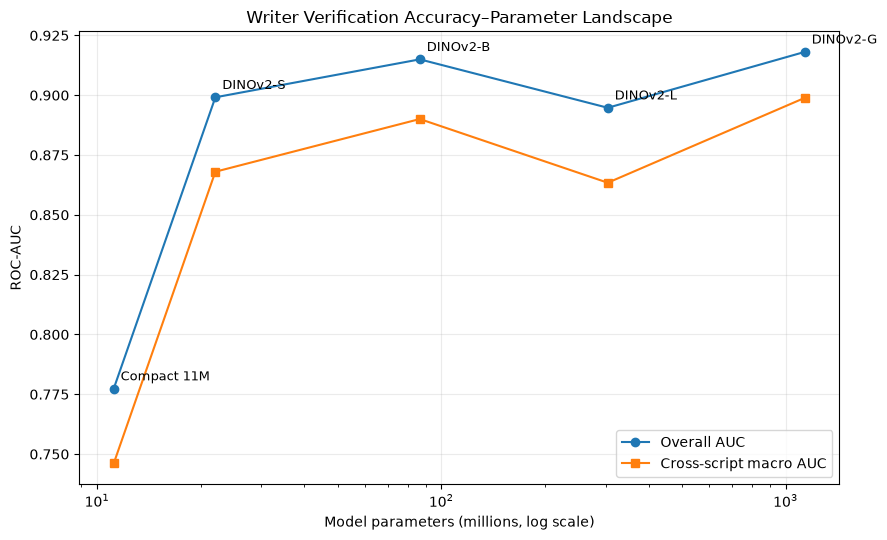

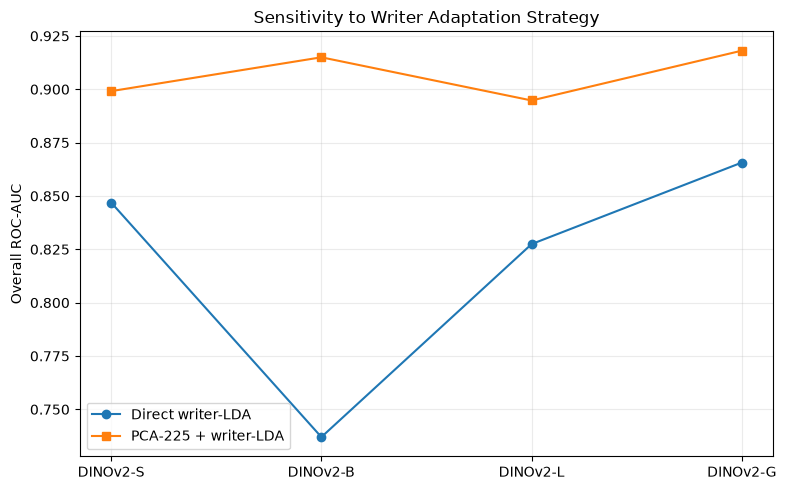

In [27]:
model_labels = {
    "compact_batch_alt": "Compact 11M",
    "dinov2_s": "DINOv2-S",
    "dinov2_b": "DINOv2-B",
    "dinov2_l": "DINOv2-L",
    "dinov2_g": "DINOv2-G",
}

plot_df = efficiency_frontier_df.copy()

plt.figure(
    figsize=(9, 5.5)
)

plt.plot(
    plot_df["parameters_m"],
    plot_df["overall_auc"],
    marker="o",
    label="Overall AUC",
)

plt.plot(
    plot_df["parameters_m"],
    plot_df["cross_script_auc"],
    marker="s",
    label="Cross-script macro AUC",
)

for row in plot_df.itertuples():
    plt.annotate(
        model_labels[row.model],
        (
            row.parameters_m,
            row.overall_auc,
        ),
        xytext=(5, 6),
        textcoords="offset points",
        fontsize=9,
    )

plt.xscale(
    "log"
)

plt.xlabel(
    "Model parameters (millions, log scale)"
)

plt.ylabel(
    "ROC-AUC"
)

plt.title(
    "Writer Verification Accuracy–Parameter Landscape"
)

plt.legend()

plt.grid(
    True,
    alpha=0.25,
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "accuracy_parameter_landscape.png",
    dpi=220,
    bbox_inches="tight",
)

plt.show()


adaptation_plot_df = (
    common_rank_comparison_df
    .set_index(
        "model"
    )
    .loc[
        [
            "dinov2_s",
            "dinov2_b",
            "dinov2_l",
            "dinov2_g",
        ]
    ]
)

x_positions = np.arange(
    len(
        adaptation_plot_df
    )
)

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    x_positions,
    adaptation_plot_df[
        "direct_lda_auc"
    ],
    marker="o",
    label="Direct writer-LDA",
)

plt.plot(
    x_positions,
    adaptation_plot_df[
        "pca225_lda_auc"
    ],
    marker="s",
    label="PCA-225 + writer-LDA",
)

plt.xticks(
    x_positions,
    [
        "DINOv2-S",
        "DINOv2-B",
        "DINOv2-L",
        "DINOv2-G",
    ],
)

plt.ylabel(
    "Overall ROC-AUC"
)

plt.title(
    "Sensitivity to Writer Adaptation Strategy"
)

plt.legend()

plt.grid(
    True,
    alpha=0.25,
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "adaptation_strategy_comparison.png",
    dpi=220,
    bbox_inches="tight",
)

plt.show()

In [28]:
expected_artifacts = [
    "efficiency_frontier_summary.csv",
    "direct_vs_pca225_lda.csv",
    "pca225_writer_lda_condition_results.csv",
    "dinov2_vits14_reg_embeddings.npz",
    "dinov2_vitb14_reg_embeddings.npz",
    "accuracy_parameter_landscape.png",
    "adaptation_strategy_comparison.png",
]

for filename in expected_artifacts:
    path = (
        REPORT_DIR
        / filename
    )

    print(
        filename,
        "| exists:",
        path.exists(),
        "| MB:",
        round(
            path.stat().st_size
            / 1024**2,
            3,
        )
        if path.exists()
        else None,
    )

print()

print(
    "Strongest overall:",
    efficiency_frontier_df.loc[
        efficiency_frontier_df[
            "overall_auc"
        ].idxmax(),
        "model",
    ],
)

print(
    "Best sub-100M DINO:",
    efficiency_frontier_df[
        (
            efficiency_frontier_df[
                "parameters_m"
            ] < 100
        )
        & (
            efficiency_frontier_df[
                "model"
            ] != "compact_batch_alt"
        )
    ]
    .sort_values(
        "overall_auc",
        ascending=False,
    )
    .iloc[0][
        "model"
    ],
)

print(
    "Official test used:",
    False,
)

efficiency_frontier_summary.csv | exists: True | MB: 0.001
direct_vs_pca225_lda.csv | exists: True | MB: 0.001
pca225_writer_lda_condition_results.csv | exists: True | MB: 0.002
dinov2_vits14_reg_embeddings.npz | exists: True | MB: 1.536
dinov2_vitb14_reg_embeddings.npz | exists: True | MB: 3.073
accuracy_parameter_landscape.png | exists: True | MB: 0.125
adaptation_strategy_comparison.png | exists: True | MB: 0.106

Strongest overall: dinov2_g
Best sub-100M DINO: dinov2_b
Official test used: False


# Final Summary — DINOv2 Efficiency Frontier

## Research Question

How does writer-verification performance scale across compact-to-giant DINOv2 representations under the same writer-disjoint QUWI protocol, and where does the current compact task-specific verifier lie on the accuracy–parameter frontier?

## Experimental Setup

The experiment used the existing QUWI writer-disjoint development and validation partitions and the same fixed 18,816-pair validation verification protocol used in earlier notebooks.

The official test split was not used.

DINOv2-S and DINOv2-B embeddings were newly extracted. Existing DINOv2-L and DINOv2-G embeddings from Notebook 19 were reused and independently re-evaluated with the same verification function, reproducing the previous results exactly.

Two development-only adaptation procedures were examined:

1. Direct writer-LDA on frozen DINOv2 embeddings.
2. A common-rank diagnostic using PCA to 225 dimensions followed by writer-LDA, where 225 corresponds to the maximum discriminant rank implied by the 226 development writers.

## Main Findings

Direct writer-LDA produced highly non-monotonic behavior. In particular, DINOv2-B achieved only 0.7370 overall AUC, while DINOv2-S achieved 0.8469 and DINOv2-G achieved 0.8657.

However, the common PCA-225 + writer-LDA diagnostic substantially changed the result:

- Compact batch-alternating verifier (~11.18M): overall AUC 0.7773, EER 29.27%, cross-script AUC 0.7461.
- DINOv2-S (~22.06M): overall AUC 0.8991, EER 17.39%, cross-script AUC 0.8680.
- DINOv2-B (~86.58M): overall AUC 0.9150, EER 16.07%, cross-script AUC 0.8900.
- DINOv2-L (~304.37M): overall AUC 0.8947, EER 17.86%, cross-script AUC 0.8634.
- DINOv2-G (~1.136B): overall AUC 0.9181, EER 15.77%, cross-script AUC 0.8989.

PCA-225 retained more than 98% of the development embedding variance for every DINOv2 model.

The largest adaptation sensitivity occurred for DINOv2-B, whose overall AUC increased from 0.7370 with direct writer-LDA to 0.9150 with PCA-225 + writer-LDA.

## Efficiency Interpretation

DINOv2-B emerged as the strongest practical efficiency point among the tested foundation models. DINOv2-G improved overall AUC over DINOv2-B by only approximately 0.0031 while using approximately 13.1 times as many parameters.

DINOv2-S was also highly competitive: with only about twice the parameters of the current compact verifier, it improved overall AUC by approximately 0.1218 and cross-script AUC by approximately 0.1219.

DINOv2-L was not on the observed accuracy-parameter Pareto frontier because smaller DINOv2-S and DINOv2-B models achieved higher verification performance under the common adaptation procedure.

## Scientific Interpretation

The results show that model size alone does not determine cross-script writer-verification quality.

They also show that conclusions about the quality of a frozen foundation representation can depend strongly on the adaptation procedure used before verification. Direct writer-LDA produced misleadingly poor performance for DINOv2-B, while a common-rank PCA preprocessing step exposed substantially stronger writer-discriminative structure.

Therefore, the direct-LDA results should be interpreted primarily as evidence of adaptation sensitivity rather than as a reliable ranking of DINOv2 representation quality.

## Limitation and Research Discipline

The PCA-225 diagnostic was introduced after observing anomalous direct-LDA behavior on the validation set. Therefore, the PCA-225 results are exploratory model-development findings rather than an unbiased final performance estimate.

No further PCA dimensionality search or validation-driven adaptation tuning should be performed in this notebook.

The PCA-225 + writer-LDA pipeline can now be frozen for future confirmation on untouched or external data.

No global state-of-the-art claim is made from these validation results.

## Decision for the Next Stage

Notebook 20 establishes that the current ~11M task-specific verifier is substantially more compact but no longer competitive in verification accuracy with efficiently adapted DINOv2 representations.

DINOv2-B provides nearly DINOv2-G-level performance at a much lower parameter count and is therefore an especially strong practical reference for future work.

The next research stage should not be chosen through additional ad hoc architecture trials. A dedicated literature and method-design review should determine whether the strongest next contribution is compact foundation-guided verification, reliability-aware probabilistic verification, or another approach that can improve accuracy while preserving the project's script-reliance and reliability analysis.